In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import numpy as np
import cartopy.crs as ccrs

In [3]:
cluster = PBSCluster(
    cores=1,
    memory='32GB',
    processes=1,
    queue='casper',
    local_directory='$TMPDIR',
    account='P93300313',
    walltime='2:00:00'
)
cluster.scale(jobs=5)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.193:36951,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
def calc_RH(T, Td):
    # Using August-Roche-Magnus approximation for sat. vapor pressure
    # calculate RH from T and Td in C
    a = 17.625
    b = 243.04
    vp_a = xr.ufuncs.exp(((a * Td) / (b + Td)))
    vp_s = xr.ufuncs.exp(((a * T)/(b + T)))
    return ((vp_a / vp_s) * 100)


def long_HI(T, RH):
    long_HI = (-42.379 + 2.04901523 * T + 10.14333127 * RH - 0.22475541 * T * RH
               - 0.00683783 * T * T - 0.05481717 * RH * RH + 0.00122874 * T * T * RH
               + 0.00085282 * T * RH * RH - 0.00000199 * T * T * RH * RH)
    return long_HI


def dry_adj(T, RH, HI):
    dry_adj = ((13 - RH) / 4) * xr.ufuncs.sqrt((17 - xr.ufuncs.abs(T - 95)) / 17)
    return dry_adj


def mid_adj(T, RH, HI):
    mid_adj = ((RH - 85) / 10) * ((87 - T) / 5)
    return mid_adj


def calc_HI(T, RH):
    # takes temperature in F and relative humidity percent
    # based on Rothfusz and Steadman papers
    # Valid for values between 20c and 50c drybulb and 0c to 30c dew
    # If this heat index value is 80 degrees F or higher, long_HI is used
    simple_HI = 0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))
    HI_test = ((simple_HI + T) / 2)
    
    HI = xr.where(HI_test >= 80, long_HI(T, RH), HI_test)
    # ds.where() evaluates callable when false, when true, returns ds
    dry_condition = HI.where(HI.notnull(), ~((RH < 13) & ((T > 80) & (T < 112))))
    mid_condition = HI.where((HI.notnull() | (dry_condition == False)), ~((RH > 85) & ((T > 80) & (T < 87))))

    HI = HI.where(dry_condition, (HI - dry_adj(T, RH, HI)))
    HI = HI.where(mid_condition, (HI + mid_adj(T, RH, HI)))
    return HI

def C_to_F(t):
    F_ds = (t * 9/5) + 32
    return F_ds

def K_to_C(t):
    return (t - 273.15)

# data import

In [5]:
tds = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/sfc_hourly_temp')
tds

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 755304, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    VAR_2T     (time, latitude, longitude) float32 30GB dask.array<chunksize=(22888, 82, 121), meta=np.ndarray>

In [6]:
dds = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/sfc_hourly_dew')
dds

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 755304, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    VAR_2D     (time, latitude, longitude) float32 30GB dask.array<chunksize=(22888, 82, 121), meta=np.ndarray>

## data check

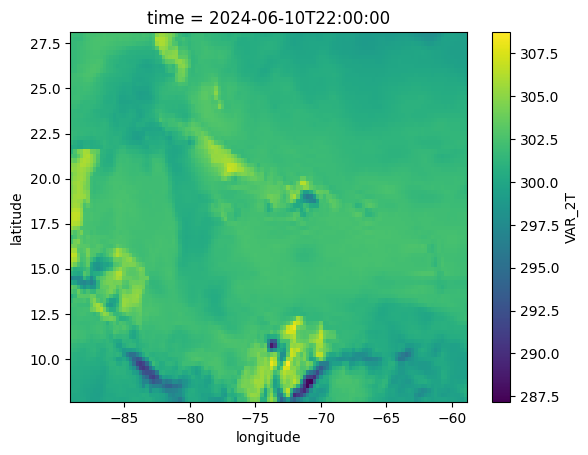

In [7]:
tds['VAR_2T'].isel(time=740230).plot()

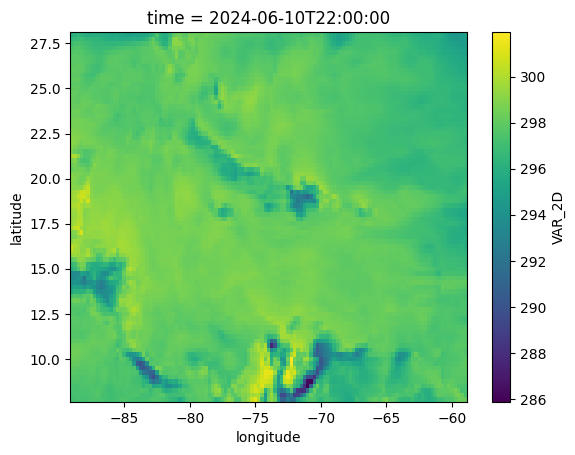

In [8]:
dds['VAR_2D'].isel(time=740230).plot()

# Calc HI

## RH using C

In [9]:
tds_C = K_to_C(tds)
dds_C = K_to_C(dds)

In [10]:
RH_da = calc_RH(tds_C['VAR_2T'], dds_C['VAR_2D']).rename('RH').drop_attrs()
RH_da

<xarray.DataArray 'RH' (time: 755304, latitude: 82, longitude: 121)> Size: 30GB
dask.array<mul, shape=(755304, 82, 121), dtype=float32, chunksize=(22888, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

## HI using F

In [11]:
tds_F = C_to_F(tds_C)
# dds_F = C_to_F(dds)

In [12]:
HI_da = calc_HI(tds_F['VAR_2T'], RH_da).drop_attrs().rename('HI_hourly')
HI_da

<xarray.DataArray 'HI_hourly' (time: 755304, latitude: 82, longitude: 121)> Size: 30GB
dask.array<where, shape=(755304, 82, 121), dtype=float32, chunksize=(22888, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

## daily max clim

In [13]:
HI_da

<xarray.DataArray 'HI_hourly' (time: 755304, latitude: 82, longitude: 121)> Size: 30GB
dask.array<where, shape=(755304, 82, 121), dtype=float32, chunksize=(22888, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [14]:
HI_dmax = HI_da.resample(time='1D').max().rename('HI_daily_max')
HI_dmax

<xarray.DataArray 'HI_daily_max' (time: 31471, latitude: 82, longitude: 121)> Size: 1GB
dask.array<transpose, shape=(31471, 82, 121), dtype=float32, chunksize=(954, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-02-28
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [15]:
HI_dmax = HI_dmax.chunk({'time': -1, 'latitude': -1, 'longitude': -1})
HI_dmax

<xarray.DataArray 'HI_daily_max' (time: 31471, latitude: 82, longitude: 121)> Size: 1GB
dask.array<rechunk-merge, shape=(31471, 82, 121), dtype=float32, chunksize=(31471, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-02-28
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

## testing plots

In [16]:
test_day = '2023-06-15'

(array([5.80000e+01, 2.10000e+02, 5.76000e+02, 1.43000e+03, 7.83700e+03,
        6.86370e+04, 1.53033e+05, 5.05300e+03, 1.21700e+03, 7.70000e+01]),
 array([ 9.6602478 , 12.65691566, 15.65358257, 18.65024948, 21.64691734,
        24.64358521, 27.64025116, 30.63691902, 33.63358688, 36.63025665,
        39.62692261]),
 <BarContainer object of 10 artists>)

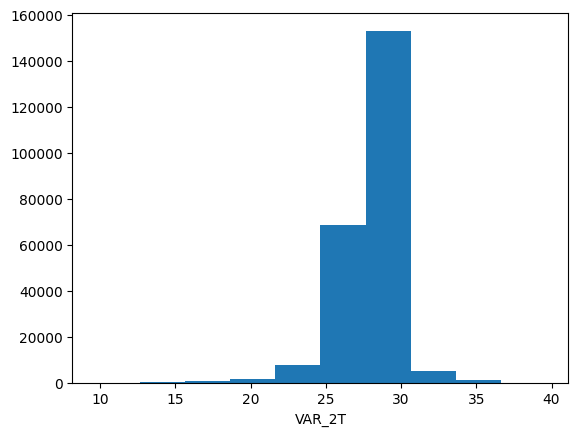

In [17]:
tds_C['VAR_2T'].sel(time=test_day).plot()

(array([5.80000e+01, 2.10000e+02, 5.76000e+02, 1.43000e+03, 7.83700e+03,
        6.86370e+04, 1.53033e+05, 5.05300e+03, 1.21700e+03, 7.70000e+01]),
 array([ 49.38844681,  54.78244781,  60.17644882,  65.57044983,
         70.96445465,  76.35845184,  81.75245667,  87.14645386,
         92.54045868,  97.9344635 , 103.32846069]),
 <BarContainer object of 10 artists>)

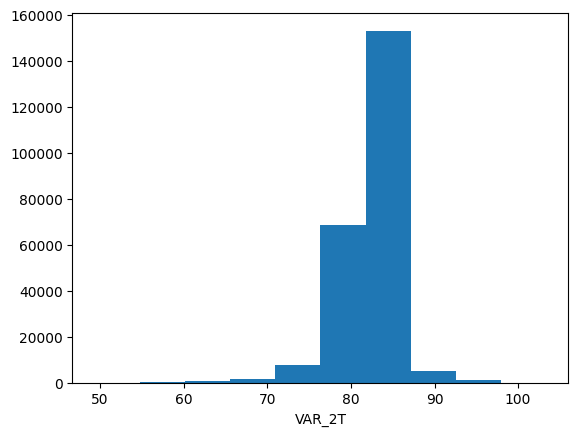

In [18]:
tds_F['VAR_2T'].sel(time=test_day).plot()

(array([3.20000e+01, 1.54000e+02, 4.73000e+02, 1.17900e+03, 2.75600e+03,
        6.02000e+03, 2.21280e+04, 1.38116e+05, 5.83250e+04, 8.94500e+03]),
 array([ 22.88873291,  30.60063171,  38.31253052,  46.02442551,
         53.73632431,  61.44822311,  69.1601181 ,  76.87201691,
         84.58391571,  92.29581451, 100.00771332]),
 <BarContainer object of 10 artists>)

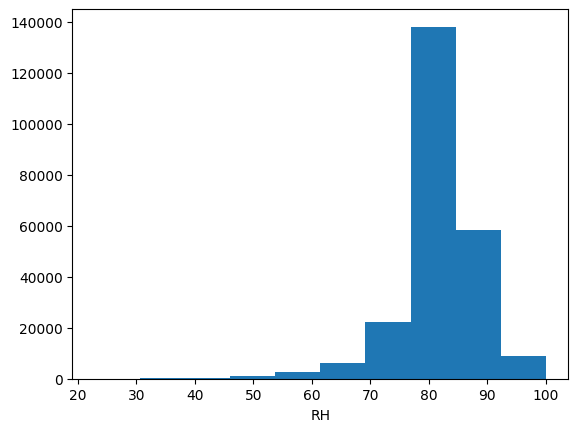

In [19]:
RH_da.sel(time=test_day).plot()

(array([8.20000e+01, 3.02000e+02, 9.22000e+02, 3.78400e+03, 1.88570e+04,
        4.44490e+04, 1.24064e+05, 4.29070e+04, 2.17300e+03, 5.88000e+02]),
 array([ 48.85725021,  55.37140274,  61.88555145,  68.39970398,
         74.91385651,  81.42800903,  87.94215393,  94.45630646,
        100.97045898, 107.48461151, 113.99876404]),
 <BarContainer object of 10 artists>)

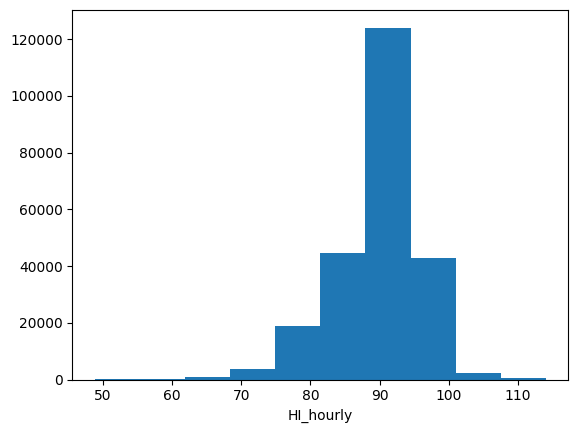

In [20]:
HI_da.sel(time=test_day).plot()

## output

In [21]:
HI_dmax.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc', mode='w')

In [22]:
HI_da.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/hourly_HI.nc', mode='w')

In [23]:
client.shutdown()